[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_06_reaction_diffusion.ipynb)


# 06. Reaction–diffusion systems and Turing patterns

_Graduate course: Introduction to Synergetics · English draft_

> **Guiding question:** How can diffusion destabilize a reaction-stable homogeneous state?

**Notebook contract.** Run from top to bottom. All parameters are dimensionless unless stated otherwise. Explain every diagnostic you use; a visually attractive trajectory is not by itself evidence of self-organization.


## Learning outcomes

By the end of this module, you should be able to:

- derive a reaction–diffusion dispersion relation
- analyze the Brusselator fixed point, Hopf threshold, and finite-wavenumber instability
- state the two-species conditions for diffusion-driven instability
- simulate a two-dimensional pattern and distinguish morphology from mechanism


## Prerequisite bridge: reaction rates and diffusion

Mass-action kinetics assigns a reaction rate proportional to the product of reactant concentrations raised to their stoichiometric powers. Combining all production and consumption terms gives local kinetics $\dot{\mathbf u}=\mathbf f(\mathbf u)$. Diffusion follows Fick's law $\mathbf j_i=-D_i\nabla u_i$; local conservation then adds $D_i\nabla^2u_i$ to each rate equation.

Diffusion normally smooths a single concentration field. In a coupled activator–inhibitor system, however, unequal diffusion changes the feedback seen by a spatial perturbation. The Turing question is therefore not “does diffusion amplify?” but “does the matrix $J-k^2D$ acquire a growing eigenmode even though $J$ is stable?” Boundary conditions determine the allowed spatial modes and must always be stated.


## Linear Turing analysis

For $\partial_t\mathbf{u}=\mathbf{f}(\mathbf{u})+D\nabla^2\mathbf{u}$, perturb a homogeneous fixed point with $\delta\mathbf{u}\propto e^{\lambda t+i\mathbf{k}\cdot\mathbf{x}}$. Then

$$\det[\lambda I-(J-k^2D)]=0.$$

A Turing instability requires the reaction fixed point to be stable at $k=0$ but unstable for a finite band of $k$. For diagonal $D=\operatorname{diag}(D_u,D_v)$ and $J=\begin{pmatrix}f_u&f_v\\g_u&g_v\end{pmatrix}$, reaction stability requires $\operatorname{tr}J<0$ and $\det J>0$. Unequal diffusion can make $\det(J-k^2D)$ negative at finite $k$.


## Brusselator: a minimal chemical dissipative structure

The Brusselator is an idealized mass-action model introduced by Prigogine and collaborators to study chemical order far from equilibrium. It is not the kinetic mechanism of the BZ reaction. Feed species maintain parameters $A$ and $B$, while intermediates $u$ and $v$ follow

$$\partial_tu=A-(B+1)u+u^2v+D_u\nabla^2u,$$
$$\partial_tv=Bu-u^2v+D_v\nabla^2v.$$

The homogeneous fixed point is $(u_*,v_*)=(A,B/A)$, with reaction Jacobian

$$J_*=\begin{pmatrix}B-1&A^2\\-B&-A^2\end{pmatrix}.$$

Because $\det J_*=A^2>0$, the well-mixed state is stable for $B<1+A^2$ and crosses a Hopf threshold at $B=1+A^2$. With unequal diffusion it can instead remain stable at $k=0$ while a finite band of spatial modes grows. This clean separation makes the model valuable for teaching, even though its species and parameters should not be mapped literally onto a particular laboratory recipe.


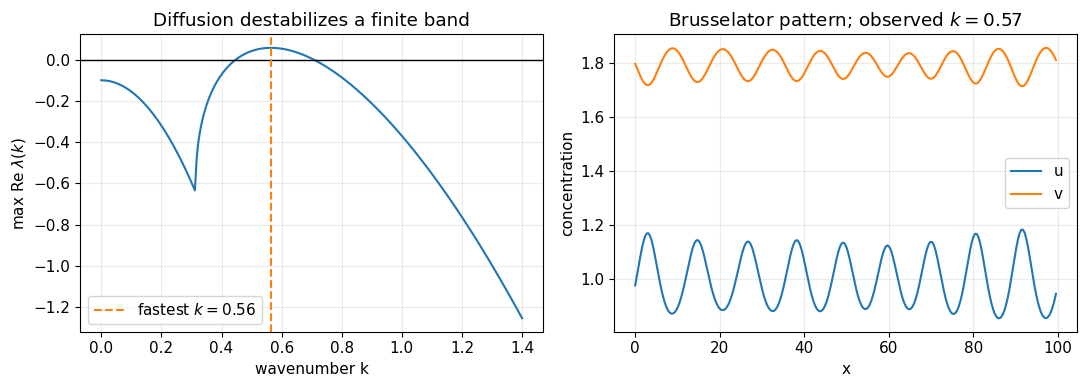

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

# Brusselator dispersion relation and a 1D reaction-diffusion realization.
A, B, Du_b, Dv_b = 1.0, 1.8, 1.0, 10.0  # B < 1 + A**2: reaction-stable
J = np.array([[B-1, A**2], [-B, -A**2]])
k_scan = np.linspace(0, 1.4, 500)
growth = np.array([
    np.max(np.linalg.eigvals(J - kk**2*np.diag([Du_b, Dv_b])).real)
    for kk in k_scan
])
k_pred = k_scan[np.argmax(growth)]

N_b, L_b, dt_b, steps_b = 256, 100.0, 0.002, 40000
dx_b = L_b/N_b
x_b = np.linspace(0, L_b, N_b, endpoint=False)
u_b = A + 0.01*rng.standard_normal(N_b)
v_b = B/A + 0.01*rng.standard_normal(N_b)

def lap_periodic_1d(z):
    return (np.roll(z, 1) - 2*z + np.roll(z, -1))/dx_b**2

for _ in range(steps_b):
    reaction = u_b*u_b*v_b
    du = A - (B+1)*u_b + reaction + Du_b*lap_periodic_1d(u_b)
    dv = B*u_b - reaction + Dv_b*lap_periodic_1d(v_b)
    u_b += dt_b*du
    v_b += dt_b*dv

power_b = np.abs(np.fft.rfft(u_b-u_b.mean()))**2
k_b = 2*np.pi*np.fft.rfftfreq(N_b, d=dx_b)
k_observed = k_b[1:][np.argmax(power_b[1:])]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_scan, growth)
ax[0].axhline(0, color="k", lw=1)
ax[0].axvline(k_pred, color="C1", ls="--", label=fr"fastest $k={k_pred:.2f}$")
ax[0].set(xlabel="wavenumber k", ylabel=r"max Re $\lambda(k)$",
          title="Diffusion destabilizes a finite band")
ax[0].legend()
ax[1].plot(x_b, u_b, label="u")
ax[1].plot(x_b, v_b, label="v")
ax[1].set(xlabel="x", ylabel="concentration",
          title=fr"Brusselator pattern; observed $k={k_observed:.2f}$")
ax[1].legend()
plt.tight_layout()


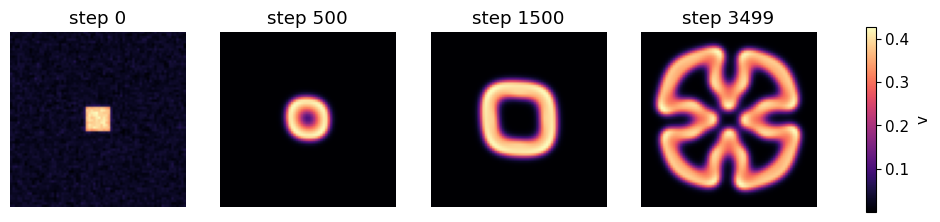

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

# Gray-Scott reaction-diffusion model with periodic boundaries.
N, steps, dt = 72, 3500, 1.0
Du, Dv, feed, kill = 0.16, 0.08, 0.060, 0.062
u = np.ones((N, N))
v = np.zeros((N, N))
s = slice(N//2-5, N//2+5)
u[s, s] = 0.50
v[s, s] = 0.25
u += 0.01*rng.standard_normal((N, N))
v += 0.01*rng.standard_normal((N, N))

def laplacian(z):
    return (np.roll(z, 1, 0) + np.roll(z, -1, 0)
            + np.roll(z, 1, 1) + np.roll(z, -1, 1) - 4*z)

frames = []
for n in range(steps):
    uvv = u*v*v
    u += dt*(Du*laplacian(u) - uvv + feed*(1-u))
    v += dt*(Dv*laplacian(v) + uvv - (feed+kill)*v)
    if n in [0, 500, 1500, steps-1]:
        frames.append((n, v.copy()))

fig, ax = plt.subplots(1, 4, figsize=(13, 3.2))
for axis, (n, field) in zip(ax, frames):
    image = axis.imshow(field, cmap="magma", origin="lower")
    axis.set_title(f"step {n}")
    axis.set_axis_off()
fig.colorbar(image, ax=ax, shrink=0.75, label="v")
plt.show()


## Interpretation boundary

Gray–Scott spots are an instructive reaction–diffusion pattern, but not every Gray–Scott parameter set is a small-amplitude classical Turing bifurcation. Establish the mechanism with the homogeneous fixed point, Jacobian, diffusion-modified spectrum, nonlinear saturation, and perturbation protocol—not from visual resemblance alone.


## Assessed exercise

For the Brusselator, derive the Hopf and Turing boundaries and classify the first instability in the $(B,D_v/D_u)$ plane for fixed $A$. Select one reaction-stable/Turing-unstable point, predict its unstable wavelength band, and compare it with simulations at two grid resolutions and two domain lengths. Contrast this evidence with the Gray–Scott morphology below.

Your submission must include a claim, the mathematical or physical reason for it, numerical evidence, and one limitation.


## Reading and attribution

**Local course reading:** Mikhailov, *Foundations of Synergetics I: Distributed Active Systems*; Haken, chemical and biological systems.

**Verified web reading:**
- [Brusselator: user-supplied orientation page](https://en.wikipedia.org/wiki/Brusselator)
- [Prigogine–Lefever symmetry-breaking paper](https://doi.org/10.1063/1.1668896)
- [NIST reaction–diffusion Brusselator](https://math.nist.gov/MatrixMarket/data/NEP/brussel/brussel.html)
- [Turing's morphogenesis paper](https://doi.org/10.1098/rstb.1952.0012)
- [Scholarpedia: reaction-diffusion systems](https://www.scholarpedia.org/article/Reaction-diffusion_systems)

The local books are course-provided sources. Web links are supplementary and were verified on 2026-09-04.
